In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pyquaternion import Quaternion
import matplotlib
import scipy

import sys 
sys.path.append("../General_Functions/")

from Flow_functions import *
from Geometric_functions import *
from Strategies import Triangulation3D

In [2]:
"""
# Simplified triangulation
def TriangulationSimple(agent_position, gradient):
    signed_gradient = np.sign(np.dot(gradient, - AgentPosition)) * gradient
    appo = signed_gradient / np.linalg.norm(signed_gradient) 
    return appo"""

'\n# Simplified triangulation\ndef TriangulationSimple(agent_position, gradient):\n    signed_gradient = np.sign(np.dot(gradient, - AgentPosition)) * gradient\n    appo = signed_gradient / np.linalg.norm(signed_gradient) \n    return appo'

In [3]:
grad = GradientStresslet  # Note: it should work with a strain or another flow
grad_name = "GradientStresslet" # For saving porpouses
e = np.array([1, 0, 0])  # orientation of the flow
Nagent = 10  # number of agent positions (in the quarter circle of radius 1)
Npoints = 60 # Resolution of space sampling
Duration = 255 # Max number of timesteps in simulations
dt = .01 # timestep lenght
AntennaeLength = .01 # Half inter-sensors distance
twist = 0.3 # Rotation around swimming direction t
x = np.linspace(0.1, 5.5, Npoints) # x axis position of the agent
z = np.linspace(0.1, 5.5, Npoints) # z axis position of the agent
X, Z = np.meshgrid(x, z) # Create 2D grid
T_mean = np.zeros((Npoints, Npoints, 3))
Perf = np.zeros((Npoints, Npoints))

In [4]:

def Evolution(n, b, t, AgentPosition, AntennaeLength, FlowGradient, e3, dt, twist):
    
    # Flow measured in the cope reference system It is basically the triangulation in 3D
    x1 = AgentPosition + AntennaeLength*n
    x2 = AgentPosition - AntennaeLength*n
    Gradient_x1 = np.dot(FlowGradient(e3, x1), n)
    Gradient_x2 = np.dot(FlowGradient(e3, x2), n)
    
    TargetDirection = Triangulation3D(x1, Gradient_x1, x2, Gradient_x2)
    
    AngularSpeed =  np.cross(t, TargetDirection) 
    Norm = np.linalg.norm(AngularSpeed)  
    
    new_n = np.copy(n)
    new_b = np.copy(b)
    new_t = np.copy(t)
    
    Rotation = Quaternion(axis=AngularSpeed, angle=dt * Norm) 
    new_n = Rotation.rotate(n)
    new_b = Rotation.rotate(b)
    new_t = Rotation.rotate(t)

    # NEW ROTATION AROUND t (it allows all trajectories to converge towards spirals)
    Rotation_t = Quaternion(axis= new_t, angle = twist * dt)
    new_n = Rotation_t.rotate(new_n)
    new_b = Rotation_t.rotate(new_b)

    new_n /= np.linalg.norm(new_n)
    new_b /= np.linalg.norm(new_b)
    new_t /= np.linalg.norm(new_t)

    
    return new_n, new_b, new_t
    

In [5]:
# initialize 
t0_Triangulation, t1_Triangulation, t2_Triangulation = np.zeros((Npoints, Npoints, Nagent)), np.zeros((Npoints, Npoints, Nagent)), np.zeros((Npoints, Npoints, Nagent))
DotProduct_Triangulation = np.zeros((Npoints, Npoints, Nagent))


for k in range(Npoints):
    for i in range(Npoints):
        AgentPosition =  np.array([z[k], x[i], 0.])
        OptimalDirection = -AgentPosition/np.linalg.norm(AgentPosition)
    
        for trials_i in range(Nagent):
            alpha, beta, gamma = (2 * np.random.rand(3) - 1) * np.pi
            RotationMatrix = Rotation(alpha, np.abs(beta), gamma)

            n_Triangulation = np.dot(RotationMatrix,[0, 1, 0])
            b_Triangulation = np.dot(RotationMatrix,[0, 0, 1])
            t_Triangulation = np.dot(RotationMatrix,[1, 0, 0])

            for time in range(Duration):
                n_Triangulation, b_Triangulation, t_Triangulation = Evolution(n_Triangulation, b_Triangulation, t_Triangulation,  AgentPosition, AntennaeLength, grad, e, dt, twist)

            t0_Triangulation[k, i, trials_i], t1_Triangulation[k, i, trials_i], t2_Triangulation[k, i, trials_i] = t_Triangulation
            DotProduct_Triangulation[k, i, trials_i] = np.dot(t_Triangulation, OptimalDirection)


# Plots

In [6]:
DotProduct_Triangulation_Mean = scipy.ndimage.gaussian_filter(np.mean(DotProduct_Triangulation, axis = 2), sigma=[1,1], mode='constant')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


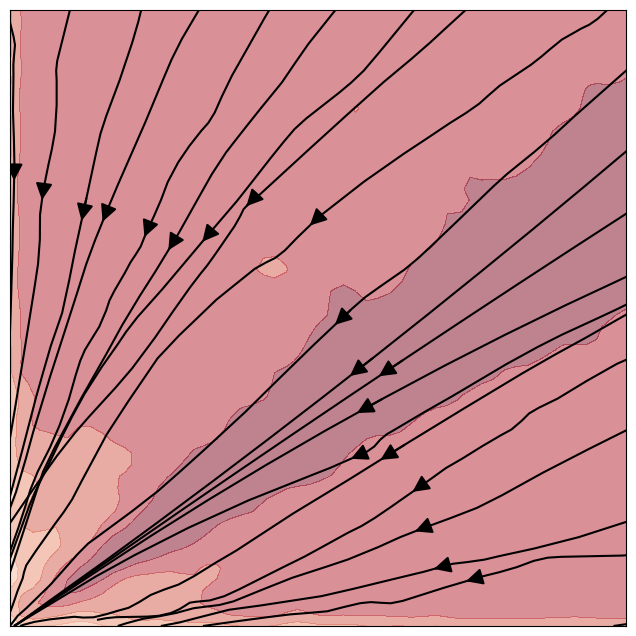

In [7]:
# Plot parameters
CMAP = 'RdBu_r' #'spring'
STREAMCOLOR = 'black'

fig1, axs = plt.subplots(nrows=1, ncols=1, figsize=(8,8), sharex='col', sharey='row')
ax1 = axs
X, Z = np.meshgrid(x, z, indexing='xy')

# Add data to image grid
levels = np.linspace(-1, 1.00001, 14)

im = ax1.contourf(X, Z, DotProduct_Triangulation_Mean, cmap = CMAP, levels = levels, vmin= -1, vmax = 1, alpha = 0.5)
ax1.streamplot(X, Z, np.mean(t1_Triangulation, axis=2), np.mean(t0_Triangulation, axis=2), color = STREAMCOLOR,  density = .35,  arrowsize = 2.5, broken_streamlines=False)
#PlotCircles(ax1, .5)
ax1.set_xlim([.1, 5])
ax1.set_ylim([.1, 5])
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_aspect("equal")


#plt.colorbar(im, ax = axs, ticks = np.arange(-1, 1.1, 0.5), location= 'bottom')
# Uncomment to save
plt.savefig("Plots/Triangulation_simulation_"+grad_name+".pdf", bbox_inches='tight')
plt.savefig("Plots/Triangulation_simulation_"+grad_name+".eps", format = 'eps', bbox_inches='tight')
plt.show()